# Projektabgabe: Diamonds
Datensatz: 
- [ggplot2::diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html)
Teammitglieder:
- Julia Tuka
- Clemens Hafenscher
- Michael Maximilian Werfring

In [55]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(gt)
library(tidyverse)
library(GGally)
library(infer)
library(ggcorrplot)
library(stringr)
library(Metrics)
library(lsr)
library(MASS)


# Train, Validation & Test Split

In [56]:
df <- ggplot2::diamonds
set.seed(123) # sorgt dafür, dass Zufall immer der selbe ist, macht script reproduzierbar.

n <- nrow(df)
idx <- sample(n) # daten durchmischen, falls diese nach einer Variale sortiert sind

train_indices <- idx[1:floor(0.6 * n)] # erste 60% des indizes
val_indices <- idx[(floor(0.6 * n) + 1):floor(0.8 * n)]
test_indices <- idx[(floor(0.8 * n) + 1):n]

train_set <- df[train_indices, ]
validation_set <- df[val_indices, ]
test_set <- df[test_indices, ]

# Deskriptive Statistik

## NA-Einträge

In [ ]:
# im diamonds dataset sind keine NA-Einträge vorhanden...
colSums(is.na(train_set)) 

# ...also setzen wir 10 Werte selbstständig auf NA
train_set$carat[sample(1:nrow(train_set), 10)] <- NA 
train_set$cut[sample(1:nrow(train_set), 10)] <- NA

# für das spätere lineare Modell, wenn NA vorhanden, wird die Zeile nicht übernommen
train_set <- train_set |> filter(!is.na(price))

# NAs behandeln, da wir nur carat und cut auf NA gesetzt haben, müssen nur 
# diese behandelt werden median aus der carat spalte berechnen ohne die na 
# Werte zu beachten
median_carat <- median(train_set$carat, na.rm = TRUE) 
# diesen median überall dort einsetzten wo wert = NA 
train_set$carat[is.na(train_set$carat)] <- median_carat 

mode_cut <- names(sort(table(train_set$cut), decreasing = TRUE))[1]
# table -> zählt häufigkeiten der vorkommenden Kategorien
# Sort -> sortiert das Array absteigend
# names [1] -> gibt den namen der ersten kategorie zurück
# modus von cut wird für die NA Werte eingesetzt
train_set$cut[is.na(train_set$cut)] <- mode_cut 

carat     cut   color clarity   depth   table   price       x       y       z 
      0       0       0       0       0       0       0       0       0       0

## Ausreißer im Datensatz

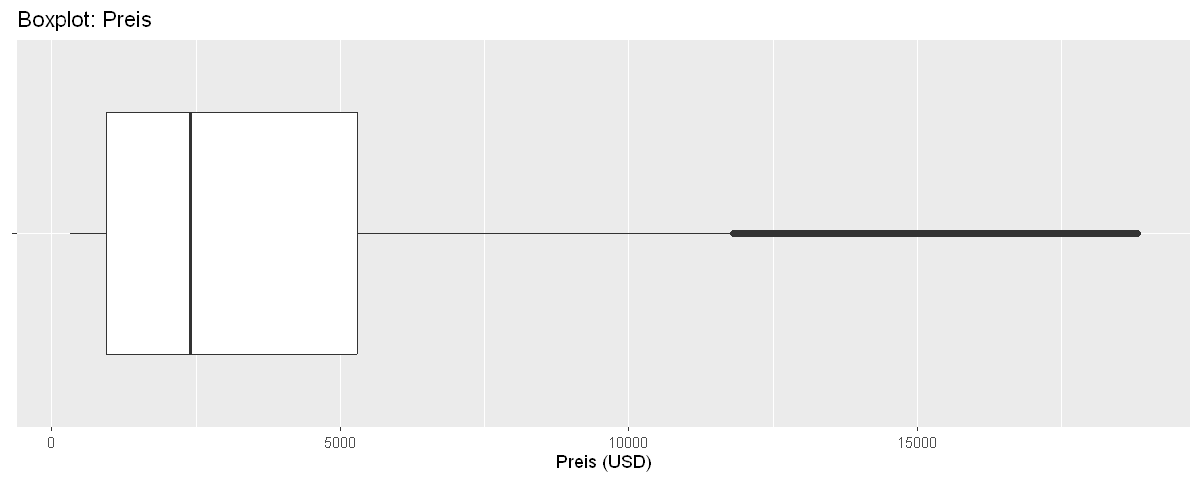

In [58]:
ggplot(train_set, aes(x = price, y = "")) +
  geom_boxplot() +
  labs(title = "Boxplot: Preis", x = "Preis (USD)", y = NULL)
# viele Ausreiße durch hohe Preise vorhanden, werden beibehalten, 
# da diese Preise in der realen Marktbeobachtung relevant sind, Diamanten
# sind ja Luxusartikel

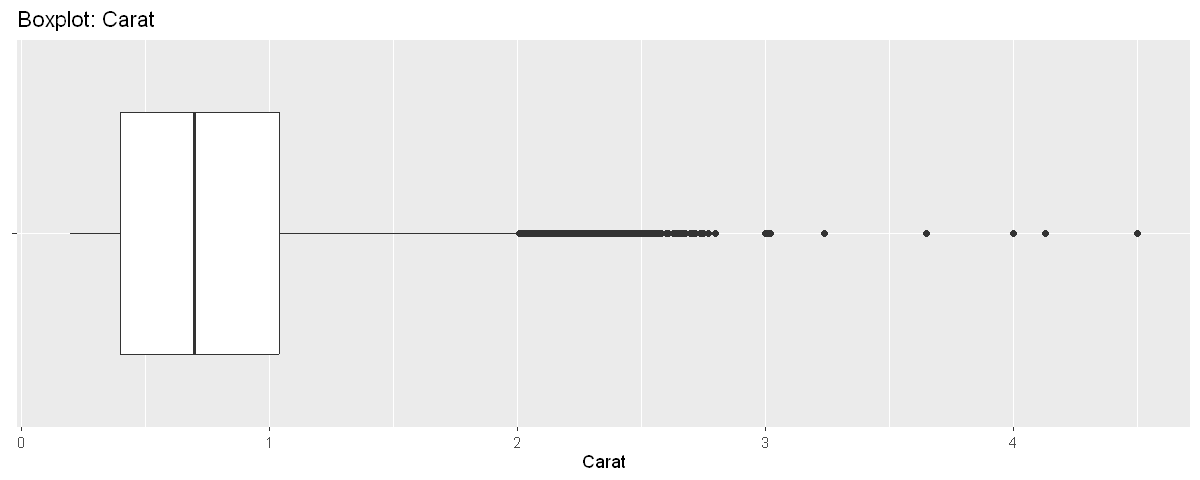

In [59]:
ggplot(train_set, aes(x = carat, y = "")) +
  geom_boxplot() +
  labs(title = "Boxplot: Carat", x = "Carat", y = NULL)
# Einige sehr große Diamanten vorhanden, meisten sind unter 1 carat, 
# Ausreißer representieren die seleteneren/wertvolleren Diamanten

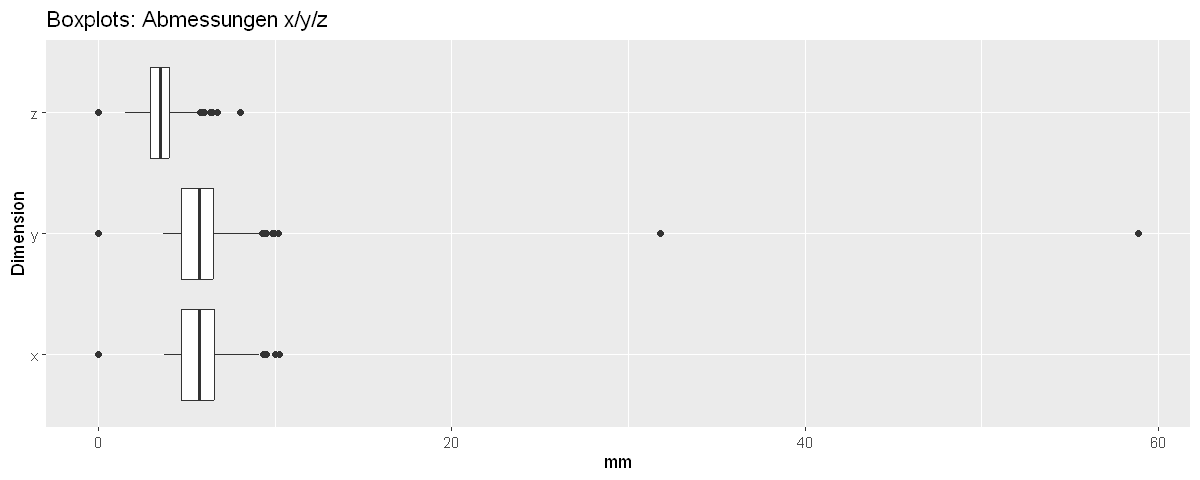

In [60]:
# par(mfrow = c(1,3))
# The next 3 plots created will be plotted next to each other
# boxplot(train_set$x, main = "x (Länge)", ylab = "mm")
# boxplot(train_set$y, main = "y (Breite)", ylab = "mm")
# boxplot(train_set$z, main = "z (Tiefe)", ylab = "mm")
# Put plotting arrangement back to its original state
# par(mfrow = c(1,1))

train_xyz_long <- train_set[, c("x", "y", "z")] |>
  pivot_longer(cols = c(x, y, z), names_to = "dimension", values_to = "mm")

ggplot(train_xyz_long, aes(x = mm, y = dimension)) +
  geom_boxplot() +
  labs(title = "Boxplots: Abmessungen x/y/z", x = "mm", y = "Dimension")
# Einzelne sehr große Werte, einige 0 Werte, diese sind nicht realistisch -> 
# sollten eventuell behandelt werden könnten Eingabe- oder Messfehler sein

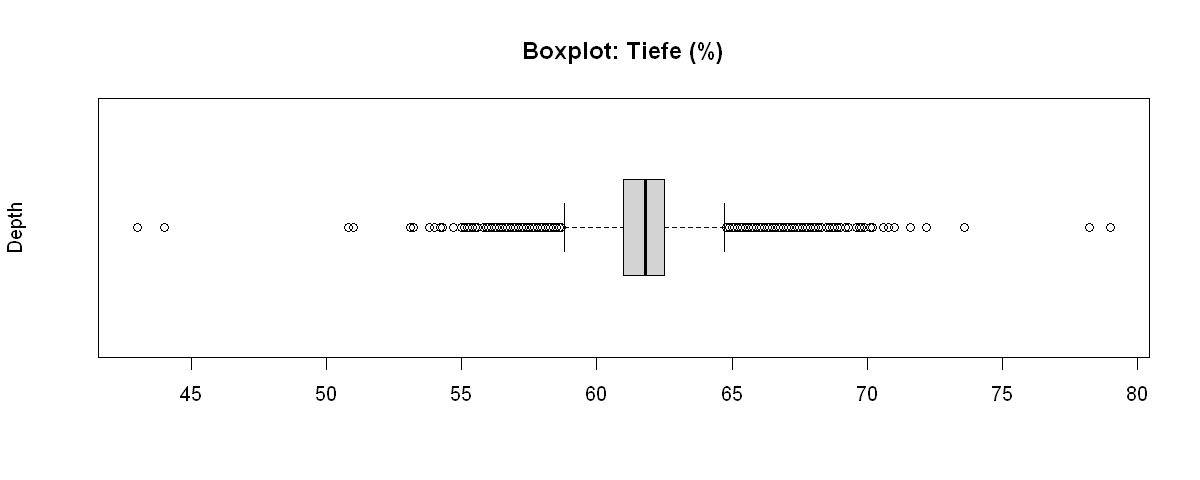

In [61]:
boxplot(train_set$depth, 
    main = "Boxplot: Tiefe (%)", 
    ylab = "Depth", horizontal = TRUE)
# moderate ausreißer mit plausiblen Werten

In [62]:
# Ausreißer behandeln: Die einzig wirklich auffälligen, 
# die nicht plausibel erscheienn sind x, y, z Werte. Siehe =>
train_set |> filter(x == 0 | y == 0 | z == 0)

# Deher werden Beobachtungen mit 'unmöglichen' Abmessungen entfernt, 
# da diese wahrscheinlich Messfehler oder Eingabefehler sind
train_set <- train_set |> filter(x > 0, y > 0, z > 0)

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1.01,Premium,H,I1,58.1,59,3167,6.66,6.60,0
0.71,Good,F,SI2,64.1,60,2130,0.00,0.00,0
1.00,Very Good,H,VS2,63.3,53,5139,0.00,0.00,0
2.20,Premium,H,SI1,61.2,59,17265,8.42,8.37,0
2.25,Premium,H,SI2,62.8,59,18034,0.00,0.00,0
2.02,Premium,H,VS2,62.7,53,18207,8.02,7.95,0
1.12,Premium,G,I1,60.4,59,2383,6.71,6.67,0
0.71,Good,F,SI2,64.1,60,2130,0.00,0.00,0
1.20,Premium,D,VVS1,62.1,59,15686,0.00,0.00,0


## Visualisierungen

In [63]:
desc_table <- train_set[, c("price", "carat")] |>
  pivot_longer(
    cols = everything(),
    names_to = "Variable",
    values_to = "Wert"
  ) |>
  group_by(Variable) |>
  summarise(
    N = n(),
    Min = min(Wert),
    Q1 = quantile(Wert, 0.25),
    Median = median(Wert),
    Mean = mean(Wert),
    Q3 = quantile(Wert, 0.75),
    Max = max(Wert),
    .groups = "drop"
  )

desc_table

Variable,N,Min,Q1,Median,Mean,Q3,Max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
carat,32352,0.2,0.4,0.7,0.7952028,1.04,4.5
price,32352,326.0,945.0,2395.0,3913.5963155,5292.00,18818.0


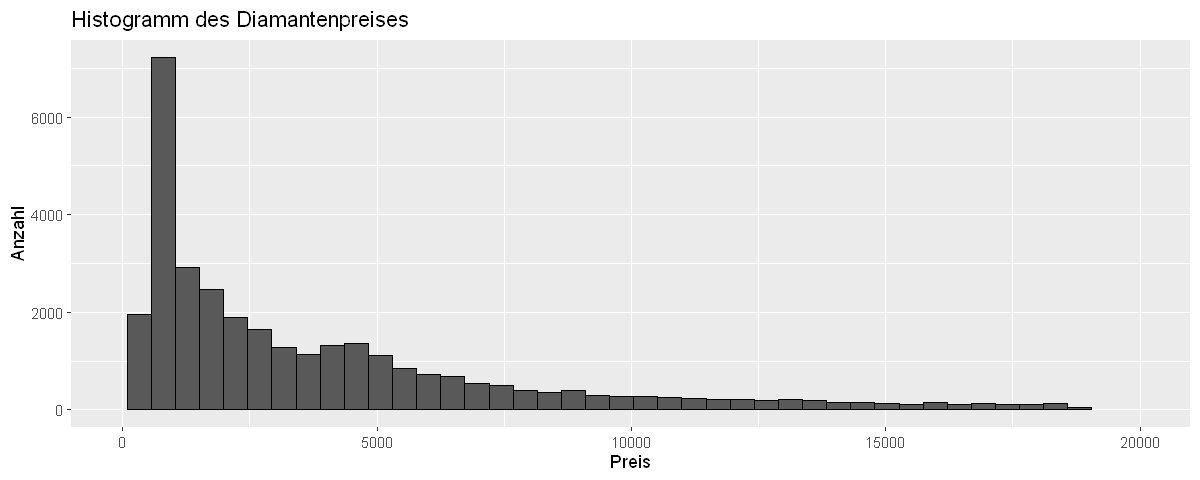

In [64]:
ggplot(train_set, aes(x = price)) +
  geom_histogram(bins = 40, color = "black") +
  coord_cartesian(xlim = c(0, 20000)) +
  labs(title = "Histogramm des Diamantenpreises", x = "Preis", y = "Anzahl")

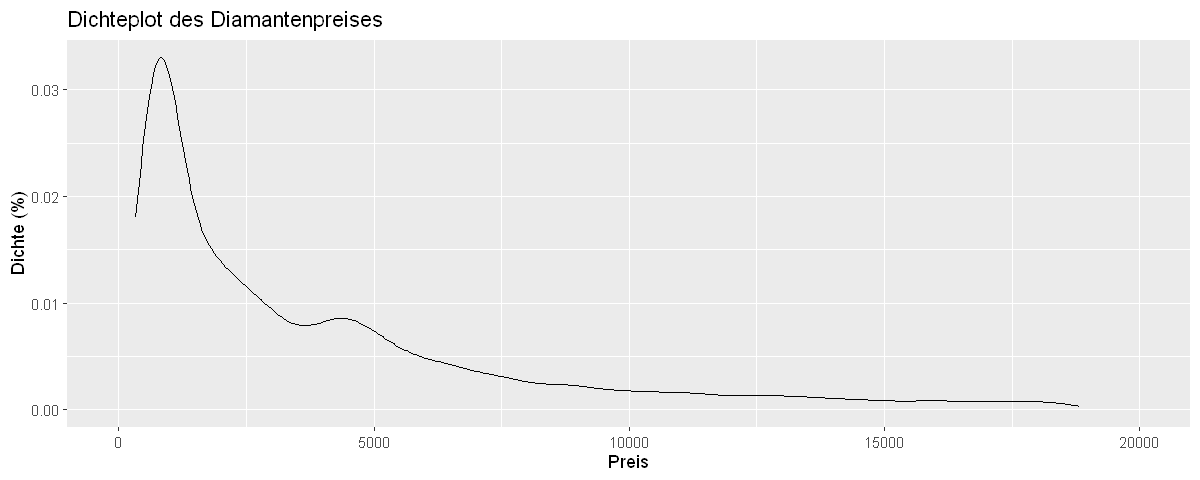

In [65]:
ggplot(train_set, aes(x = price)) +
  geom_density(aes(y = after_stat(density * 100))) +
  coord_cartesian(xlim = c(0, 20000)) +
  labs(title = "Dichteplot des Diamantenpreises", x = "Preis", y = "Dichte (%)")

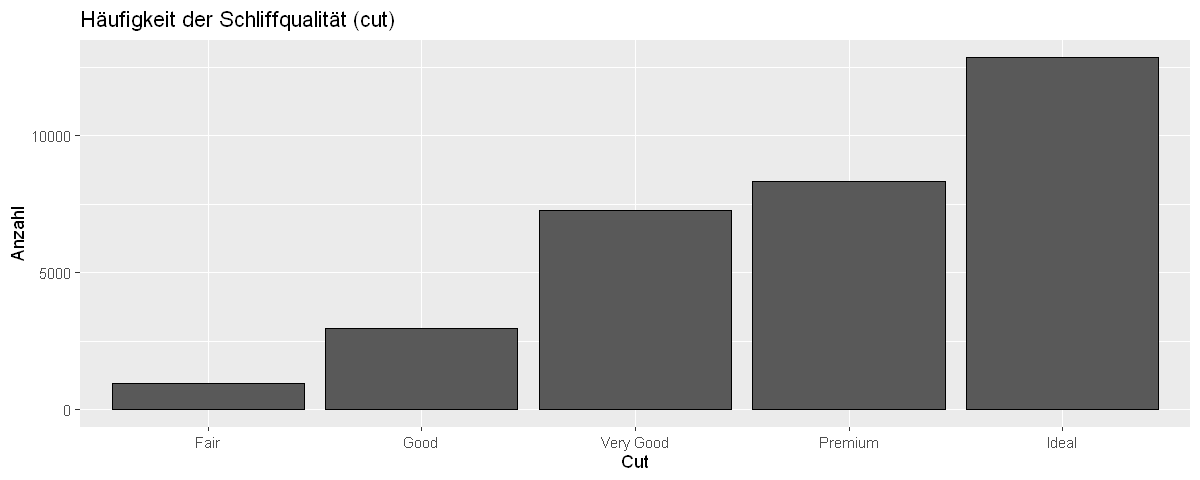

In [66]:
ggplot(train_set, aes(x = cut)) +
  geom_bar(color = "black") +
  labs(title = "Häufigkeit der Schliffqualität (cut)", x = "Cut", y = "Anzahl")

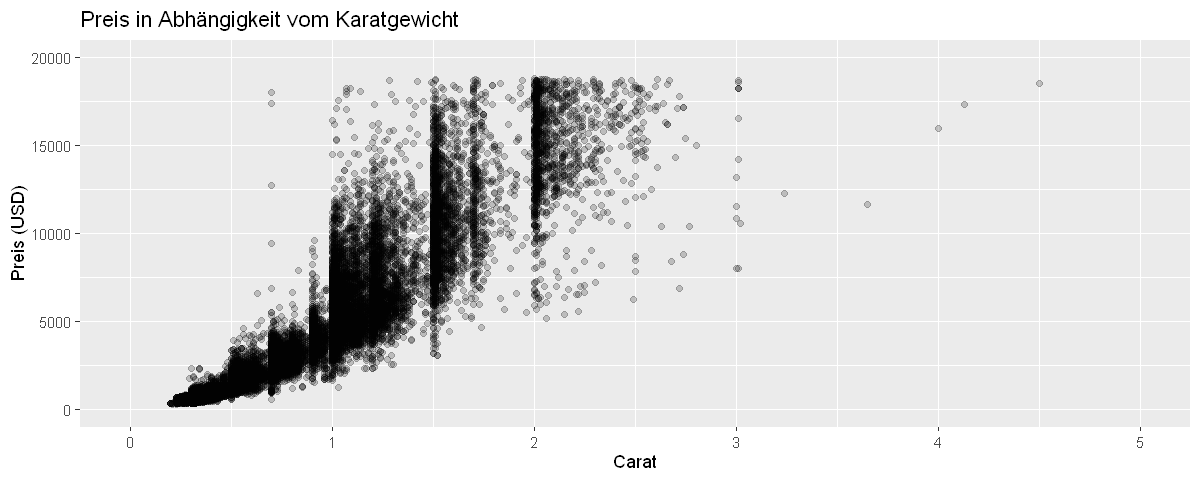

In [67]:
ggplot(train_set, aes(x = carat, y = price)) +
  geom_point(alpha = 0.2) +
  coord_cartesian(xlim = c(0, 5), ylim = c(0, 20000)) +
  labs(title = "Preis in Abhängigkeit vom Karatgewicht", 
  x = "Carat", y = "Preis (USD)")

# Induktive Statistik

In [68]:
df <- ggplot2::diamonds
df |> head()

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


## Inference
For inference the variable **depth** was chosen. It describes the height of a diamond from the **table** (flat top surface) to the **cutlet** (tip at the bottom) and can be measured in millimeters. In this Dataset it is relative to the width of the diamond, so it must be interpreted as a percentage. See [here](https://www.diamonds.pro/education/diamond-depth-and-table/) for further information.

In [69]:
confidence_level <- 0.95
q_lower <- (1 - confidence_level) / 2
q_upper <- q_lower + confidence_level

df |>
  pull(depth) |>
  quantile(c(q_lower, q_upper)) |>
  print() # For better formatting

 2.5% 97.5% 
 58.6  64.4 


## Test for Normal Distribution
The histogram and the qq-plot show pretty clearly that a normal distribution is very unlikely to be present. First we will create functions to plot our data against normal distribution.

In [70]:
options(repr.plot.width = 10, repr.plot.height = 4) # make plot wider

plot_depth_agains_norm <- function(df) {
    # scale standard-normal distribution with our data
    m <- mean(df$depth)
    s <- sd(df$depth)

    norm_density <- function(x) dnorm(x, 
        mean = m,
        sd = s
    )

    df |> 
    ggplot(aes(x = depth)) +
    geom_histogram(aes(y = after_stat(density)), bins = 70, 
                   fill = "#cccccc", color = "white", alpha = 0.85) + 
    geom_density(linewidth = 1.2, color = "#0073C2FF") +
    geom_function(fun = norm_density, 
                  linewidth = 1.2, color = "#006b3d", linetype = "dashed") +
    theme_minimal(base_size = 14) +
    labs(
        title = "Diamond Depth Distribution vs. Normal Curve",
        subtitle = paste0( # concats strings with no separator
            "Blue line = Sample Distribution
            Dashed Green = Normal Distribution 
            (µ=", round(m, 1), ", σ=", round(s, 1), ")"),
        x = "depth (%)",
        y = "density",
    ) +
    theme(
        panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold")
    )
}

qq_plot_depth <- function(df) {
    df |> 
    ggplot(aes(sample = depth)) + 
    stat_qq(color = "#0073C2FF") + 
    stat_qq_line(color="#006b3d", linewidth=1.5 , alpha=0.7) + 
    labs(title = "QQ-Plot depth", 
        x = "Quantiles Normaldistribution", 
        y = "Quantiles depth")
}

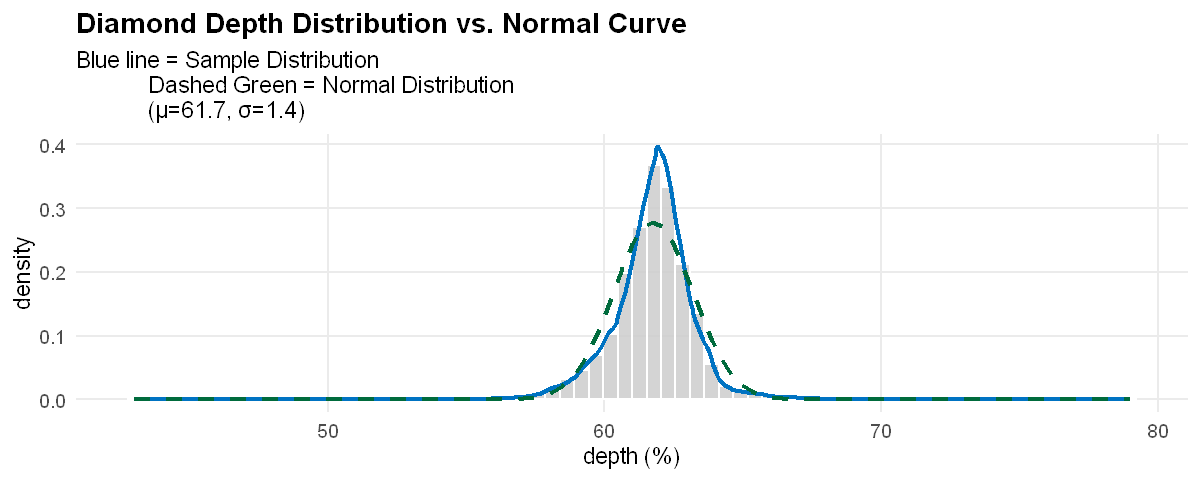

In [71]:
plot_depth_agains_norm(df)

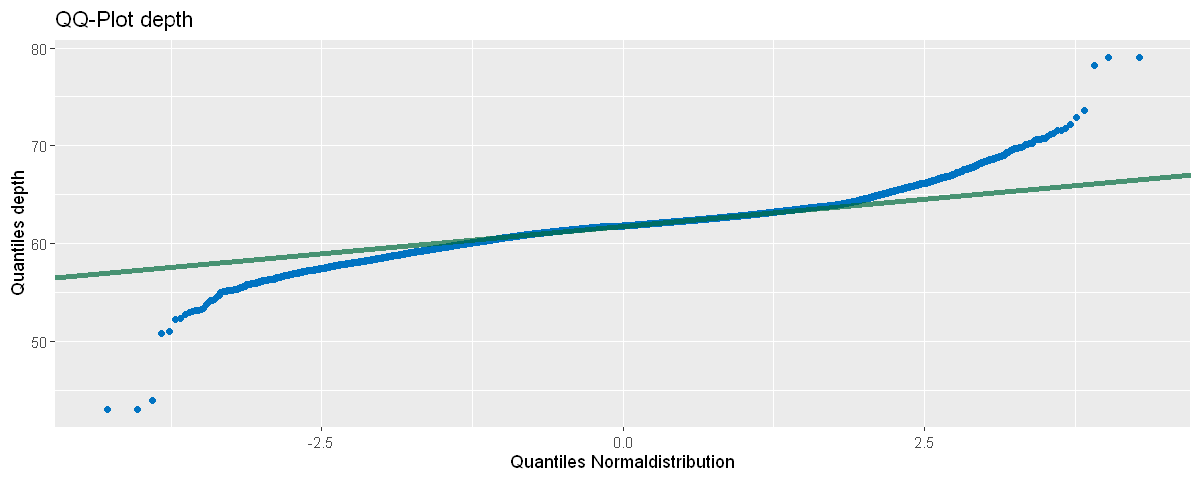

In [72]:
qq_plot_depth(df)

Lets try if removing the smallest and largest 1% of data would possibly improve the fit.

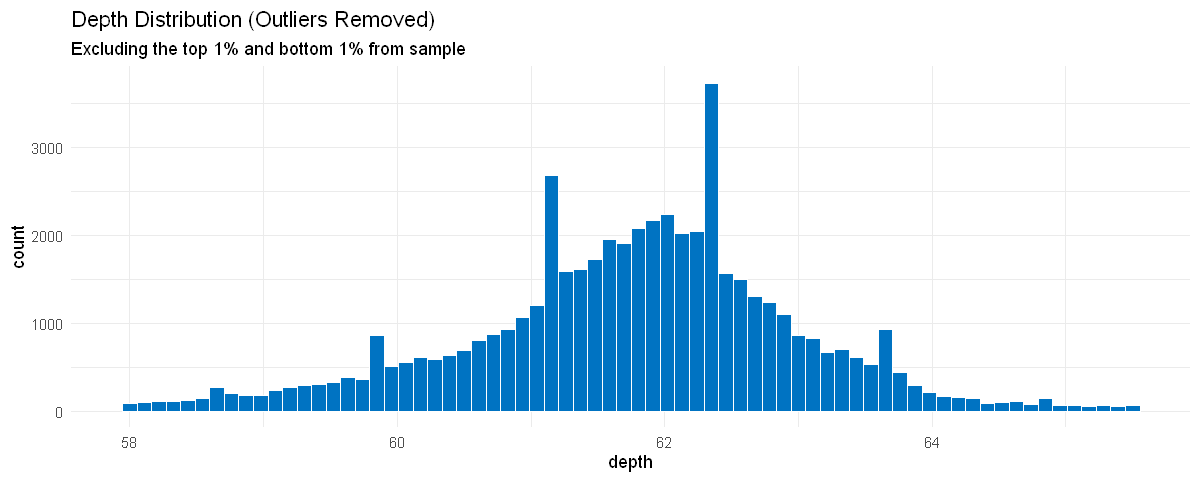

In [73]:
df_filtered <- df |>
    filter(depth > quantile(depth, 0.01, na.rm = TRUE),
           depth < quantile(depth, 0.99, na.rm = TRUE))

df_filtered |>
    ggplot(aes(x = depth)) +
    geom_histogram(bins = 70, fill = "#0073C2FF", color = "white") +
    theme_minimal() +
    labs(title = "Depth Distribution (Outliers Removed)",
         subtitle = "Excluding the top 1% and bottom 1% from sample")

We see in the histogram, that both functions came closer to each other but the qq-plot still shows some discrepancies. As expected mu has not changed but sigma did.

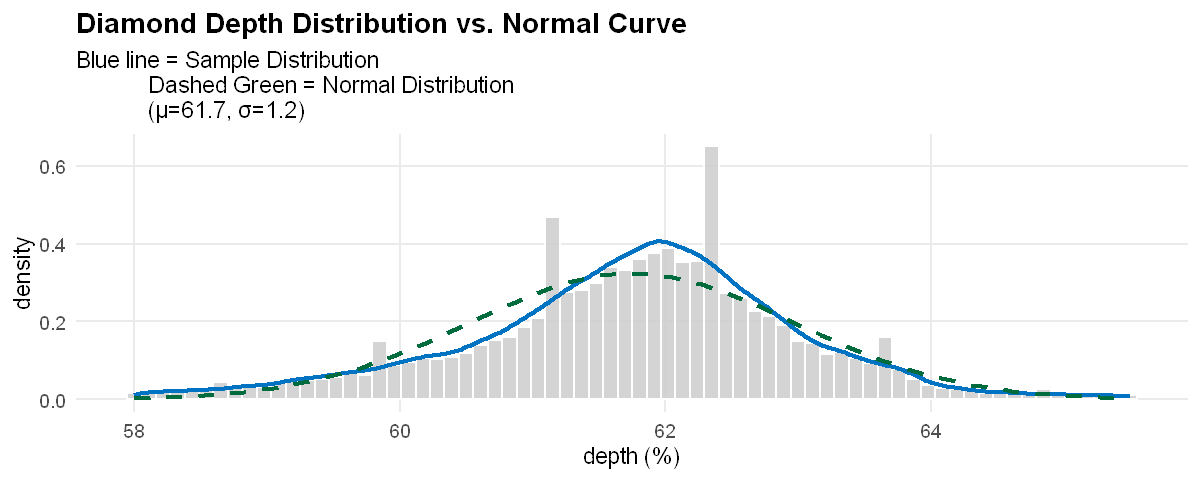

In [74]:
plot_depth_agains_norm(df_filtered)

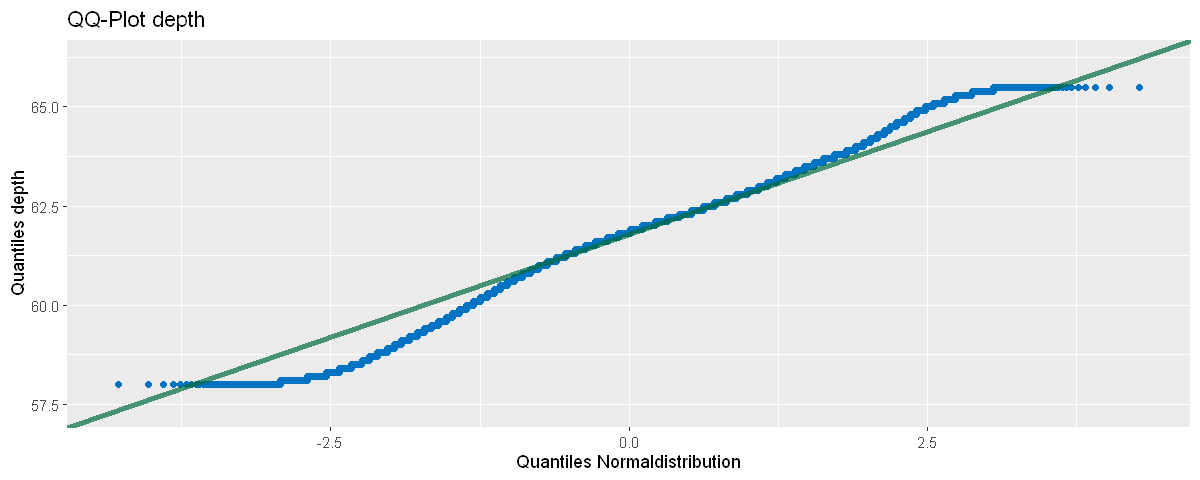

In [75]:
qq_plot_depth(df_filtered)

We can now test our **df** againts normal distribution to validate the assumptions from our plots.
Lets assume that: \
**H0:** "depth" follows normal distribution \
**H1:** "depth" does not follow normal distribution

In [76]:
ks.test(
    x = df$depth,
    y = "pnorm", # Test against normal distribution
    mean = mean(df$depth),
    sd = sd(df$depth),
    alternative = "two.sided" # Standard value
)

Warning message in ks.test.default(x = df$depth, y = "pnorm", mean = mean(df$depth), :
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  df$depth
D = 0.075871, p-value < 2.2e-16
alternative hypothesis: two-sided


We can see from the Kolmogorov-Smirnov test, that the p-value is very small so we need to **reject H0**. Now lets test **df_filtered** for normal distribution to see if sacrificing 2% of our data was worth it. Again we state that:
**H0:** "depth" follows normal distribution
**H1:** "depth" does not follow normal distribution


In [77]:
ks.test(
    x = df_filtered$depth, # now we use filtered data
    y = "pnorm", # Test against normal distribution
    mean = mean(df_filtered$depth),
    sd = sd(df_filtered$depth),
    alternative = "two.sided" # Standard value
)

Warning message in ks.test.default(x = df_filtered$depth, y = "pnorm", mean = mean(df_filtered$depth), :
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  df_filtered$depth
D = 0.062968, p-value < 2.2e-16
alternative hypothesis: two-sided


Again p-value is really small so we have to **reject H0**. In conclusion it can be said, that there is very strong evidence, that our data (filtered and unfiltered) does not follow normal distribution.

## Directed T-Test
Based on our extensive knowledge about diamonds we came to the conclusion that the depth of a diamond has some kind of influence on its cut. This means that a diamond with a "Fair" cut should be more shallow than a diamond with an "Ideal" cut according to [this](https://www.diamondguidance.com/education/diamond-grading/4-cs/cut/fair/) article.

We state our Hypothesis like this:
**H0**: Mean depth of "Fair" cut diamonds is less than (or equal) to the mean depth of "Ideal" cut diamonds
**H1**: Mean depth of "Fair" cut diamonds is greater than the mean depth of "Ideal" cut diamonds

In [78]:
df_fair_ideal <- df |> filter(cut == "Fair" | cut == "Ideal")

df_fair_ideal |> t_test(
    formula = depth ~ cut, # compare depth, groups defined by cut
    alternative = "greater", # also see H1
    order = c("Fair", "Ideal"),
    conf_level = 0.95,
)

statistic,t_df,p_value,alternative,estimate,lower_ci,upper_ci
<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
25.64795,1618.363,2.514919e-122,greater,2.332276,2.182617,Inf


Since the p-value is very small (basically zero) we can **reject H0** and have strong evidence based on our data that the mean depth of "Fair" cut diamonds is grater than the mean depth of "Ideal" cut diamonds. Based on the conf_level of 95% and the lower_ci being at about 2.18% we can also state that we have 95% confidence that "Fair" cut diamonds are 2.18% deeper than "Ideal" cut diamonds.

# Lineare Regression

## Correlation
Below we create a correlation Matrix for all the numeric values from our train set. We see that there is strong positive correlation between the price, carat and the xyz values. While there is very little correlation between price and depth and table. Also the variables carat and x, y and z are positively correlated, which makes perfect sense due to the fact that carat is the weight of the diamond and x, y and z are length, width and depth of the diamond (in mm). [Official Documentation](https://ggplot2.tidyverse.org/reference/diamonds.html)

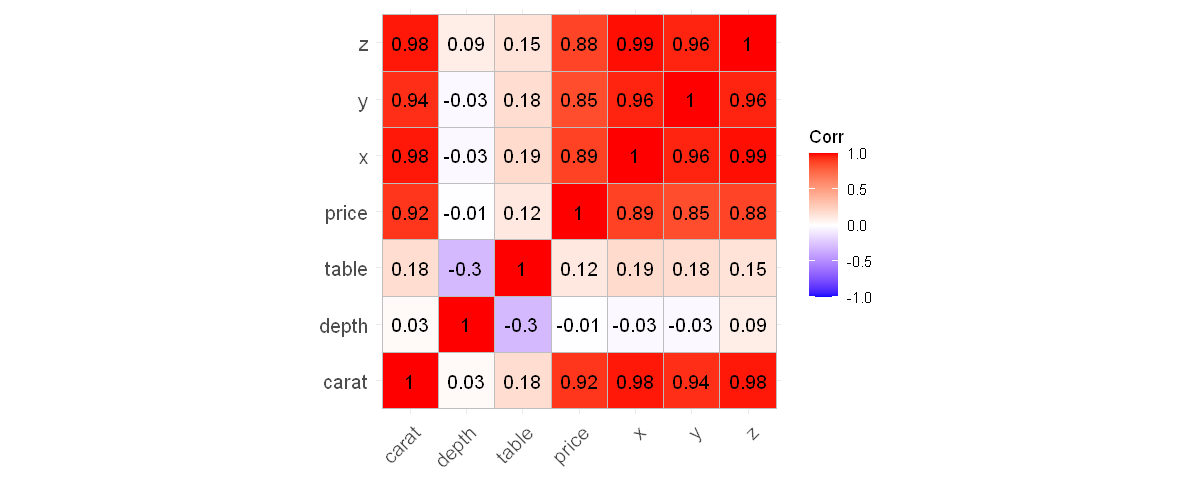

In [79]:
# Create correlation Matrix
train_corel <- train_set |>
  dplyr::select(where(is.numeric)) |>
  cor() |>
  round(digits = 2)

# Display correlation plot, easier to us than just correlation Matrix
ggcorrplot(train_corel, lab = TRUE)

## Creating Linear Models
Based on our insights from the previous sections we create 4 linear models with the following variables to predict a diamonds price: \
- **model1**: carat, x, y, z (naive approach, just use all variables that have high correlate with price)
- **model2**: carat, depth, table, x, y, z (use all numeric variables)
- **model3**: carat, cut, color, clarity, depth, table, x, y, z (all variables available)
- **model4**: carat, cut, color, clarity (based on [this article](https://4cs.gia.edu/en-us/4cs-of-diamond-quality/) these influence the quality and maybe also the price)

In [80]:
model1 <- lm(price ~ carat + x + y + z, data = train_set)
coef(model1) |>
  print() # pretty formatting

(Intercept)       carat           x           y           z 
  2985.0239  10897.2981   -159.3904    230.7853  -2303.9138 


In [81]:
model2 <- lm(price ~ carat + depth + table + x + y + z, data = train_set)
coef(model2) |>
  print()

(Intercept)       carat       depth       table           x           y 
18969.91635 10983.88100  -165.48857  -102.07337 -1056.06250    82.73102 
          z 
 -603.43504 


In [82]:
model3 <- lm(price ~ carat + cut + color + clarity + depth + table + x + y + z, 
data = train_set)
coef(model3) |>
  print()

 (Intercept)        carat        cut.L        cut.Q        cut.C        cut^4 
  733.233441 11506.988282   563.621509  -282.197593   128.756448     8.740099 
     color.L      color.Q      color.C      color^4      color^5      color^6 
-1919.476699  -645.965520  -168.955314    63.527826   -89.869021   -30.058165 
   clarity.L    clarity.Q    clarity.C    clarity^4    clarity^5    clarity^6 
 4059.828875 -1909.338005   950.775288  -356.870283   236.162830    13.963781 
   clarity^7        depth        table            x            y            z 
   88.870568    26.384856   -27.932385  -233.850990   123.680190 -1671.695926 


In [83]:

model4 <- lm(price ~ carat + cut + color + clarity, data = train_set)
coef(model4) |>
  print()

 (Intercept)        carat        cut.L        cut.Q        cut.C        cut^4 
-3681.260768  8872.838336   684.630197  -313.066000   159.045941    15.857643 
     color.L      color.Q      color.C      color^4      color^5      color^6 
-1866.918332  -595.198208  -175.927479    45.284737   -77.251384   -33.356088 
   clarity.L    clarity.Q    clarity.C    clarity^4    clarity^5    clarity^6 
 4185.343272 -1810.774959   888.682975  -352.603794   218.802968     7.636444 
   clarity^7 
  109.825386 


In [84]:
# Ranking der wichtigsten Effekte (nach absolutem Betrag) -> 
# keine Standardisierung
rank_betas <- function(model, top_n = NULL, remove_intercept = TRUE) {
  df <- coef(model) |>
    tibble::enframe(name = "term", value = "beta") |>
    mutate(abs_beta = abs(beta))

  # Bedingung außerhalb der Pipe anwenden
  if (remove_intercept) {
    df <- df |> filter(term != "(Intercept)")
  }

  df <- df |> arrange(desc(abs_beta))

  if (!is.null(top_n)) {
    df <- head(df, top_n)
  }

  return(df)
}

## Model Ranking

In [85]:
cat("\n====== MODEL 1: price ~ carat + x + y + z ======\n")
rank_m1 <- rank_betas(model1)
print(rank_m1, n = nrow(rank_m1))


====== MODEL 1: price ~ carat + x + y + z ======
# A tibble: 4 × 3
  term    beta abs_beta
  <chr>  <dbl>    <dbl>
1 carat 10897.   10897.
2 z     -2304.    2304.
3 y       231.     231.
4 x      -159.     159.


In [86]:
cat("\n====== MODEL 2: price ~ carat + depth + table + x + y + z ======\n")
rank_m2 <- rank_betas(model2)
print(rank_m2, n = nrow(rank_m2))


====== MODEL 2: price ~ carat + depth + table + x + y + z ======
# A tibble: 6 × 3
  term     beta abs_beta
  <chr>   <dbl>    <dbl>
1 carat 10984.   10984. 
2 x     -1056.    1056. 
3 z      -603.     603. 
4 depth  -165.     165. 
5 table  -102.     102. 
6 y        82.7     82.7


In [87]:
cat("\n====== MODEL 3: price ~ carat + cut + color + clarity + 
depth + table + x + y + z ======\n")
rank_m3 <- rank_betas(model3)
print(rank_m3, n = 20)  # viele Terme durch Faktoren


====== MODEL 3: price ~ carat + cut + color + clarity + 
depth + table + x + y + z ======
# A tibble: 23 × 3
   term         beta abs_beta
   <chr>       <dbl>    <dbl>
 1 carat     11507.   11507. 
 2 clarity.L  4060.    4060. 
 3 color.L   -1919.    1919. 
 4 clarity.Q -1909.    1909. 
 5 z         -1672.    1672. 
 6 clarity.C   951.     951. 
 7 color.Q    -646.     646. 
 8 cut.L       564.     564. 
 9 clarity^4  -357.     357. 
10 cut.Q      -282.     282. 
11 clarity^5   236.     236. 
12 x          -234.     234. 
13 color.C    -169.     169. 
14 cut.C       129.     129. 
15 y           124.     124. 
16 color^5     -89.9     89.9
17 clarity^7    88.9     88.9
18 color^4      63.5     63.5
19 color^6     -30.1     30.1
20 table       -27.9     27.9
# ℹ 3 more rows


In [88]:
cat("\n====== MODEL 4: price ~ carat + cut + color + clarity ======\n")
rank_m4 <- rank_betas(model4)
print(rank_m4, n = 20)


====== MODEL 4: price ~ carat + cut + color + clarity ======
# A tibble: 18 × 3
   term          beta abs_beta
   <chr>        <dbl>    <dbl>
 1 carat      8873.    8873.  
 2 clarity.L  4185.    4185.  
 3 color.L   -1867.    1867.  
 4 clarity.Q -1811.    1811.  
 5 clarity.C   889.     889.  
 6 cut.L       685.     685.  
 7 color.Q    -595.     595.  
 8 clarity^4  -353.     353.  
 9 cut.Q      -313.     313.  
10 clarity^5   219.     219.  
11 color.C    -176.     176.  
12 cut.C       159.     159.  
13 clarity^7   110.     110.  
14 color^5     -77.3     77.3 
15 color^4      45.3     45.3 
16 color^6     -33.4     33.4 
17 cut^4        15.9     15.9 
18 clarity^6     7.64     7.64


In [89]:
model_stats <- function(model) {
  s <- summary(model)

  list(
    t_tests = s$coefficients,      # T-Tests der Regressionskoeffizienten
    f_test = s$fstatistic,         # F-Test des Gesamtmodells
    r2 = s$r.squared,              # R²
    adj_r2 = s$adj.r.squared,      # Adjusted R²
    aic = AIC(model)               # AIC
  )
}

stats_m1 <- model_stats(model1)
stats_m2 <- model_stats(model2)
stats_m3 <- model_stats(model3)
stats_m4 <- model_stats(model4)

## Modelle Übersicht

In [90]:
cat("===== MODEL 1: price ~ carat + x + y + z =====\n")
print(stats_m1$t_tests)
cat("\nF-Test:\n")
print(stats_m1$f_test)
cat("\nR²:", stats_m1$r2, "| adj. R²:", stats_m1$adj_r2, "\n")
cat("AIC:", stats_m1$aic, "\n\n")

===== MODEL 1: price ~ carat + x + y + z =====
              Estimate Std. Error    t value      Pr(>|t|)
(Intercept)  2985.0239  144.70666  20.628104  6.188344e-94
carat       10897.2981   87.42329 124.649835  0.000000e+00
x            -159.3904   61.35110  -2.598004  9.380984e-03
y             230.7853   26.64268   8.662240  4.836798e-18
z           -2303.9138   96.83812 -23.791393 4.781897e-124

F-Test:
   value    numdf    dendf 
48470.75     4.00 32347.00 

R²: 0.8570172 | adj. R²: 0.8569995 
AIC: 565258.5 



In [91]:
cat("===== MODEL 2: price ~ carat + depth + table + x + y + z =====\n")
print(stats_m2$t_tests)
cat("\nF-Test:\n")
print(stats_m2$f_test)
cat("\nR²:", stats_m2$r2, "| adj. R²:", stats_m2$adj_r2, "\n")
cat("AIC:", stats_m2$aic, "\n\n")

===== MODEL 2: price ~ carat + depth + table + x + y + z =====
               Estimate  Std. Error    t value      Pr(>|t|)
(Intercept) 18969.91635 1067.222757  17.775030  2.386481e-70
carat       10983.88100   86.490134 126.995768  0.000000e+00
depth        -165.48857   16.577788  -9.982548  1.965059e-23
table        -102.07337    3.929776 -25.974346 3.134854e-147
x           -1056.06250  147.650368  -7.152454  8.704805e-13
y              82.73102   31.996938   2.585592  9.725528e-03
z            -603.43504  265.570568  -2.272221  2.307970e-02

F-Test:
   value    numdf    dendf 
33183.98     6.00 32345.00 

R²: 0.8602499 | adj. R²: 0.860224 
AIC: 564522.6 



In [92]:
cat("===== MODEL 3: price ~ carat + cut + color + clarity + depth + 
table + x + y + z =====\n")
print(stats_m3$t_tests)
cat("\nF-Test:\n")
print(stats_m3$f_test)
cat("\nR²:", stats_m3$r2, "| adj. R²:", stats_m3$adj_r2, "\n")
cat("AIC:", stats_m3$aic, "\n\n")

===== MODEL 3: price ~ carat + cut + color + clarity + depth + 
table + x + y + z =====
                Estimate Std. Error     t value      Pr(>|t|)
(Intercept)   733.233441  865.72393   0.8469599  3.970238e-01
carat       11506.988282   67.08425 171.5303921  0.000000e+00
cut.L         563.621509   29.17011  19.3218842  1.030497e-82
cut.Q        -282.197593   23.32193 -12.1000948  1.247282e-33
cut.C         128.756448   20.07481   6.4138322  1.438646e-10
cut^4           8.740099   16.04369   0.5447685  5.859165e-01
color.L     -1919.476699   22.36050 -85.8423094  0.000000e+00
color.Q      -645.965520   20.36636 -31.7172795 1.948690e-217
color.C      -168.955314   19.03331  -8.8768240  7.226225e-19
color^4        63.527826   17.51511   3.6270292  2.871418e-04
color^5       -89.869021   16.54150  -5.4329432  5.583169e-08
color^6       -30.058165   15.01336  -2.0020940  4.528296e-02
clarity.L    4059.828875   39.78496 102.0443196  0.000000e+00
clarity.Q   -1909.338005   37.22085 -51.2975

In [93]:
cat("===== MODEL 4: price ~ carat + cut + color + clarity =====\n")
print(stats_m4$t_tests)
cat("\nF-Test:\n")
print(stats_m4$f_test)
cat("\nR²:", stats_m4$r2, "| adj. R²:", stats_m4$adj_r2, "\n")
cat("AIC:", stats_m4$aic, "\n\n")

===== MODEL 4: price ~ carat + cut + color + clarity =====
                Estimate Std. Error      t value      Pr(>|t|)
(Intercept) -3681.260768   18.14629 -202.8658079  0.000000e+00
carat        8872.838336   15.58298  569.3929250  0.000000e+00
cut.L         684.630197   26.47861   25.8559705 6.366332e-146
cut.Q        -313.066000   23.31054  -13.4302316  5.181292e-41
cut.C         159.045941   20.15874    7.8896779  3.124677e-15
cut^4          15.857643   16.11222    0.9841998  3.250247e-01
color.L     -1866.918332   22.87299  -81.6210937  0.000000e+00
color.Q      -595.198208   20.84346  -28.5556318 3.801549e-177
color.C      -175.927479   19.51473   -9.0151129  2.072136e-19
color^4        45.284737   17.95260    2.5224616  1.165843e-02
color^5       -77.251384   16.96143   -4.5545335  5.269345e-06
color^6       -33.356088   15.39649   -2.1664737  3.028229e-02
clarity.L    4185.343272   40.59732  103.0940677  0.000000e+00
clarity.Q   -1810.774959   38.08909  -47.5405142  0.000000e

## RMSE

In [94]:
## RMSE
rmse_model <- function(model, train_data, val_data) {
  pred_train <- predict(model, train_data)
  pred_val   <- predict(model, val_data)

  rmse_train <- rmse(train_data$price, pred_train)
  rmse_val   <- rmse(val_data$price, pred_val)

  return(list(train_rmse = rmse_train, val_rmse = rmse_val))
}

rmse_m1 <- rmse_model(model1, train_set, validation_set)
rmse_m2 <- rmse_model(model2, train_set, validation_set)
rmse_m3 <- rmse_model(model3, train_set, validation_set)
rmse_m4 <- rmse_model(model4, train_set, validation_set)

cat("===== MODEL 1 =====\n")
print(rmse_m1)

cat("\n===== MODEL 2 =====\n")
print(rmse_m2)

cat("\n===== MODEL 3 =====\n")
print(rmse_m3)

cat("\n===== MODEL 4 =====\n")
print(rmse_m4)

===== MODEL 1 =====
$train_rmse
[1] 1505.595

$val_rmse
[1] 1518.872


===== MODEL 2 =====
$train_rmse
[1] 1488.477

$val_rmse
[1] 1489.194


===== MODEL 3 =====
$train_rmse
[1] 1130.658

$val_rmse
[1] 1130.535


===== MODEL 4 =====
$train_rmse
[1] 1159.729

$val_rmse
[1] 1146.878



Model 3 is has the best RMSE Score, followed closely by Model 4, for the next plots we will use the best Model (3).

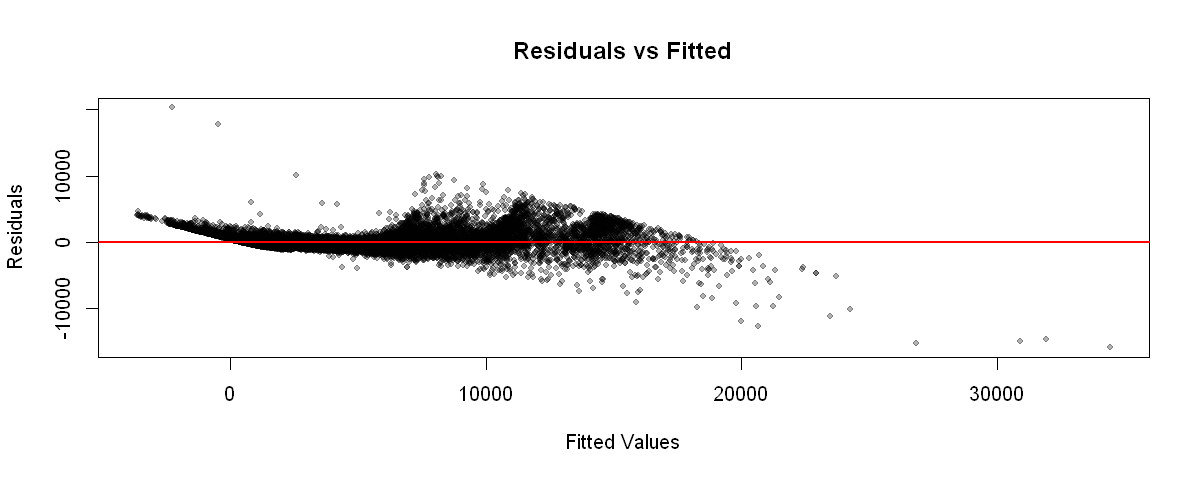

In [95]:
res <- residuals(model3)
fitted_vals <- fitted(model3)

# Residuen vs. Fitted Plot (Homoskedastizität)
plot(fitted_vals, res,
     main = "Residuals vs Fitted",
     xlab = "Fitted Values",
     ylab = "Residuals",
     pch = 20, col = rgb(0, 0, 0, 0.3))
abline(h = 0, col = "red", lwd = 2)

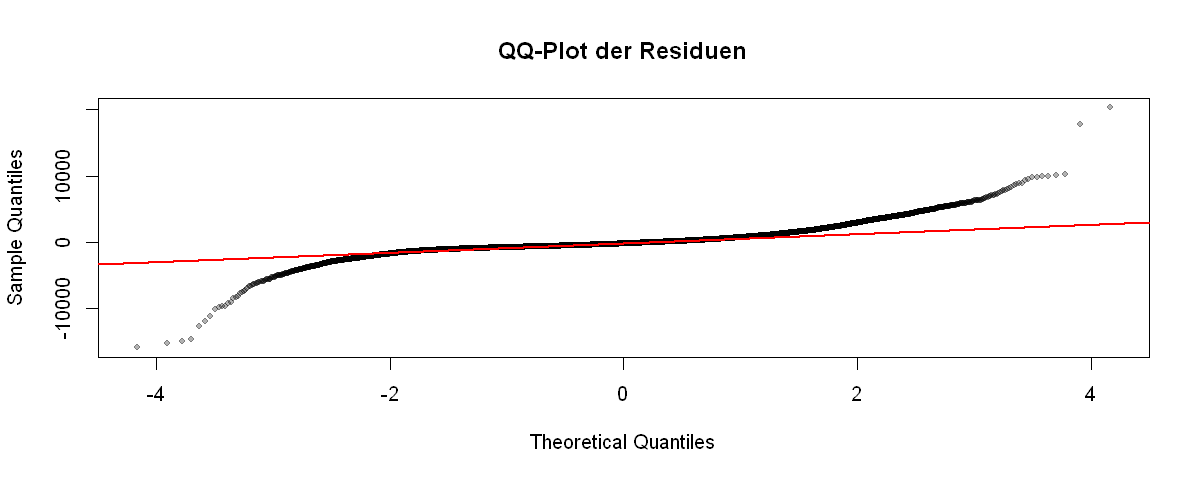

In [96]:
qqnorm(res, main = "QQ-Plot der Residuen", pch = 20, col = rgb(0, 0, 0, 0.3))
qqline(res, col = "red", lwd = 2)

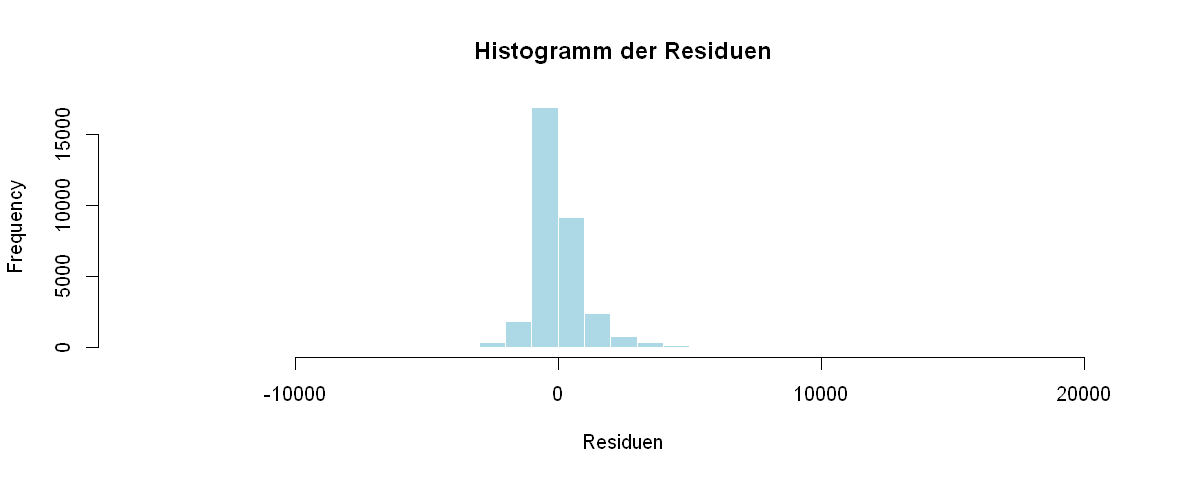

In [97]:
hist(res, breaks = 50,
     main = "Histogramm der Residuen",
     xlab = "Residuen",
     col = "lightblue", border = "white")

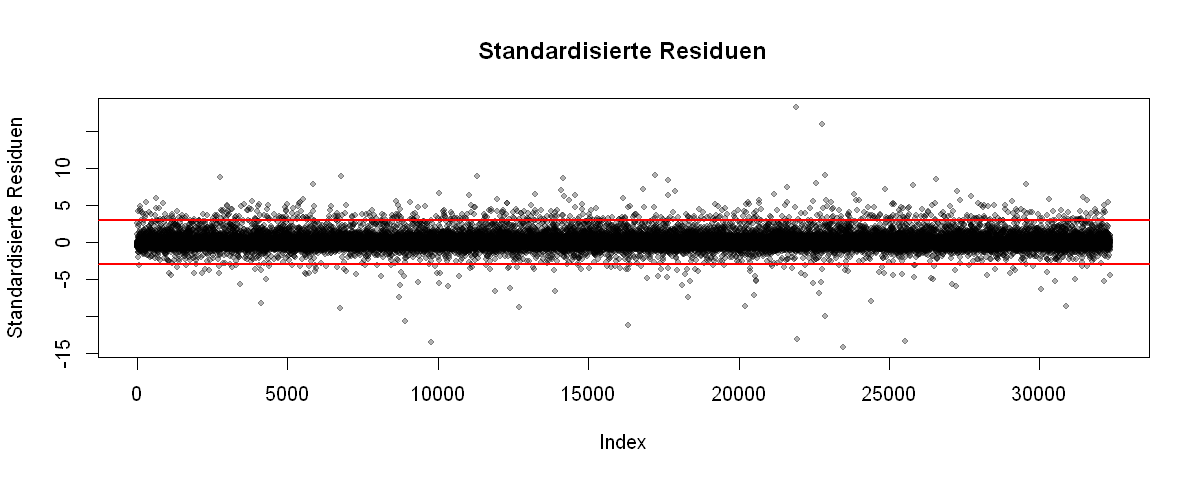

In [98]:
std_res <- studres(model3)

plot(std_res,
     main = "Standardisierte Residuen",
     ylab = "Standardisierte Residuen",
     xlab = "Index",
     pch = 20, col = rgb(0, 0, 0, 0.3))
abline(h = c(-3, 3), col = "red", lwd = 2)

## Prognose am Test-Set

In [99]:
# ---- Prognose für das Test-Set ----
pred_test <- predict(model3, test_set)

# ---- RMSE berechnen ----
rmse_test <- rmse(test_set$price, pred_test)

cat("RMSE Test-Set (Modell 3):", rmse_test, "\n")

rmse_test_all <- function(model, name) {
  pred <- predict(model, test_set)
  val <- rmse(test_set$price, pred)
  cat(name, ": ", val, "\n")
}

rmse_test_all(model1, "Model 1")
rmse_test_all(model2, "Model 2")
rmse_test_all(model3, "Model 3")
rmse_test_all(model4, "Model 4")

RMSE Test-Set (Modell 3): 1258.175 
Model 1 :  1704.629 
Model 2 :  1559.429 
Model 3 :  1258.175 
Model 4 :  1180.247 


Hier zeigt sich, dass Modell 4 im Gegensatz zu vorher auf den Testdaten besser abschneidet als Modell 3. Das könnte daran liegen, dass Modell 3 mehr Variablen beinhaltet und somit overfittet.